# Methodology preparation

## Image Union Section
What pixel range of the 7DT image can we use?


- Are pixel-wcs informations of images same?

In [2]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.stats import sigma_clipped_stats
import matplotlib.pyplot as plt
import numpy as np
import glob
from pathlib import Path

# Image preparation
COSMOS = 1
PROJECT_ROOT = Path("..")
DATA_ROOT = Path("../COSMOS_data")

def get_image_path(cosmos, band, weight=False):
    image_folder = DATA_ROOT / f"COSMOS{cosmos}"

    suffix = "weight.fits" if weight else "com.fits"
    paths = list(image_folder.glob(f"*{band}*.{suffix}"))

    if len(paths) == 0:
        print(
            f"COSMOS {cosmos} - {band}: no matching {suffix} file."
        )
        return None

    if len(paths) > 1:
        raise RuntimeError(
            f"COSMOS {cosmos} - {band}: multiple matching {suffix} files."
        )

    return paths[0]


# 1. Check a "same pixel - same WCS" assumtion
bands_7DT = sorted({f'm{i}' for i in range(400, 900, 25)})

# Check sample image
with fits.open(get_image_path(COSMOS, "m400")) as sample_hdul :
    sample_hdul.info() 
    sample_data = sample_hdul[0].data
    sample_header = sample_hdul[0].header

# sample image plot
# norm = ImageNormalize(sample_data, interval=ZScaleInterval() )
# plt.imshow(
#     sample_data,
#     origin='lower',
#     cmap='gray', 
#     norm=norm
# )

# check basic statistics of sample image
mean, median, std = sigma_clipped_stats(
    data=sample_data, 
    sigma=3.0
)
print(
    f"mean : {mean} \nmedian : {median}\nstd : {std}"
)
print(f"max : {sample_data.max()} min : {sample_data.min()}")

# check outer region pixel value
print("Outer region pixel value : ", sample_data[6750, 10000]) # 0.0
    

Filename: ../COSMOS_data/COSMOS1/calib_7DT_COSMOS_1_20240528_234348_m400_4320.com.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     343   (10200, 6800)   float32   
mean : 1.0566397905349731 
median : 0.8473065495491028
std : 1.9300025701522827
max : 86451.8828125 min : -124.08546447753906
Outer region pixel value :  0.0


**Result : pixel-wcs is same for all bands**

In [11]:
# WCS value of test pixel in each bands
# test pixel : 5100, 3400(middle) - by hdul info 
test_list = []

for band in bands_7DT:
    band_path = get_image_path(COSMOS, band)
    if band_path == None : continue
    
    with fits.open(band_path) as hdul : 
        data = hdul[0].data
        header = hdul[0].header
    wcs = WCS(header)
    ra, dec = wcs.pixel_to_world_values(5100, 3400)
    test_list.append( np.array([ra, dec]) )

for i in test_list : 
    print(i)

[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]
[149.79992982   1.95007014]


- Make mask in that all bands have a value.

In [12]:
# check sample weight
# Check sample image
with fits.open(get_image_path(COSMOS, "m400", weight=True)) as sample_hdul :
    sample_hdul.info() 
    sample_data = sample_hdul[0].data
    sample_header = sample_hdul[0].header

# sample image plot
# plt.imshow(sample_data, origin='lower')

# check outer region pixel value
print("Outer region pixel value : ", sample_data[6750, 10000]) 
print("Inner region pixel value : ", sample_data[3400, 5100])
# d = sample_data.ravel()
# plt.hist(d, bins=500)
# plt.show()


Filename: ../COSMOS_data/COSMOS1/calib_7DT_COSMOS_1_20240528_234348_m400_4320.weight.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     293   (10200, 6800)   float32   
Outer region pixel value :  0.0
Inner region pixel value :  0.22374818


We can determine edge using weight file. And we can make **boolean mask array**.

In [3]:
valid_mask = None

for band in bands_7DT:
    band_path = get_image_path(COSMOS, band, weight=True)
    if band_path == None : continue
    
    with fits.open(band_path) as hdul : 
        weight = hdul[0].data
        header = hdul[0].header
    valid = weight > 0.0
    
    if valid_mask is None : 
        valid_mask = valid
    else : 
        valid_mask &= valid


# # make mask fits
# plt.imshow(valid_mask)
# plt.colorbar()
valid_mask = valid_mask.astype(np.uint8)
with fits.open(get_image_path(COSMOS, "m400", weight=True)) as sample_hdul :
    sample_header = sample_hdul[0].header
    mask_header = sample_header.copy()
    
fits.writeto(
    DATA_ROOT/f"COSMOS{COSMOS}/COSMOS{COSMOS}_validmask.fits", 
    valid_mask, 
    header=mask_header, 
    overwrite=True
)


## Check S/N ratio 
- Calculate S/N ratio of COSMOS images.
- applying S/N cut >> compare before/after catalog source plot 
- Check source distance

Image pixel scale : [0.505 0.505]
3 arcsec : [5.94059406 5.94059406] pix
<TableColumns names=('pixel_centroid_x','pixel_centroid_y','world_centroid_alpha','world_centroid_delta','aperture_flux','aperture_flux_err','aperture_mag','aperture_mag_err','aperture_flags','mask')>


**Number of sources**
SnR >= 5
Original data : 3815
after flag cut : 3569
after SnR cut : 2249


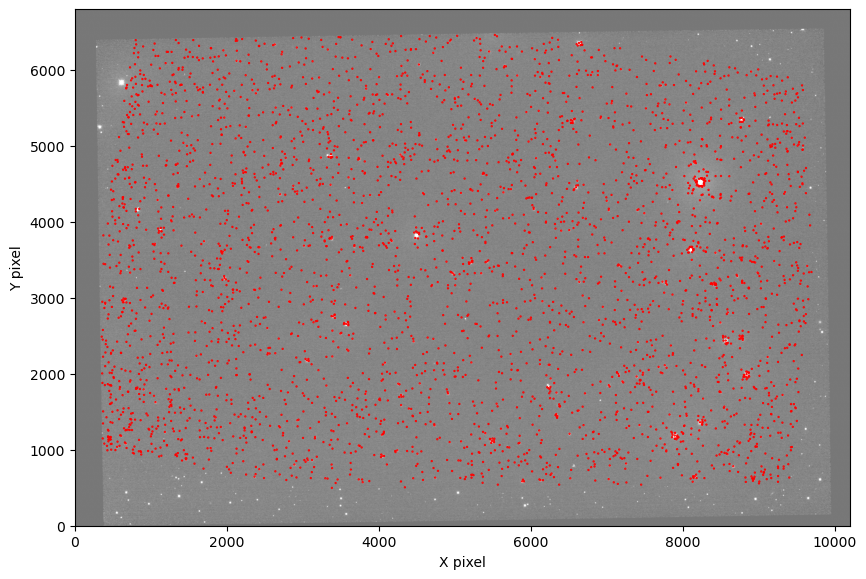

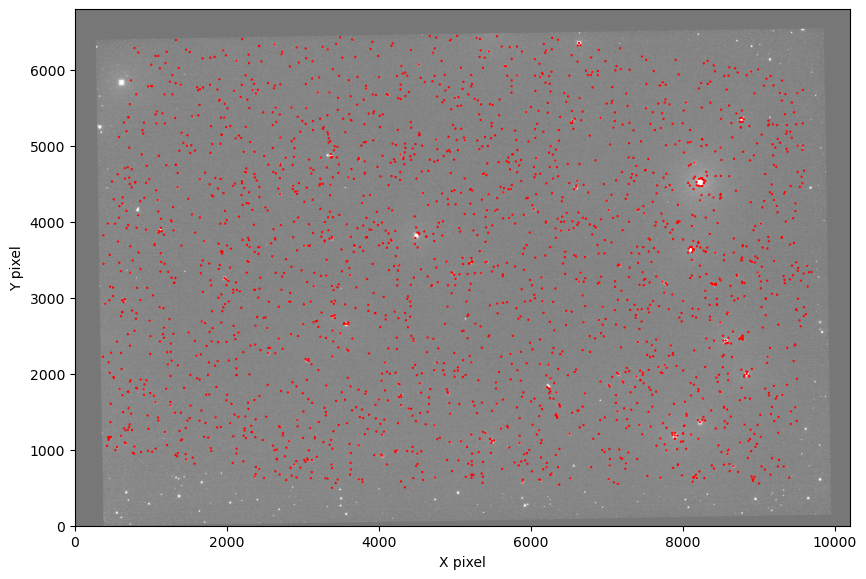

In [4]:
from astropy.table import Table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from matplotlib.patches import Circle

def get_catalog_path(cosmos, band):
    return PROJECT_ROOT / f'output/COSMOS{cosmos}/COSMOS_{cosmos}_cat_{band}.fits'

def plot_ImageAndDetectedSources(image, cat, pixel_range=None):
    # pixel_range = np.array([[xmin, xmax], [ymin, ymax]])

    if pixel_range is not None:
        xmin = pixel_range[0][0]
        xmax = pixel_range[0][1]
        ymin = pixel_range[1][0]
        ymax = pixel_range[1][1]

        cat_plot = cat[
            (xmin <= cat['pixel_centroid_x'])
            & (cat['pixel_centroid_x'] < xmax)
            & (ymin <= cat['pixel_centroid_y'])
            & (cat['pixel_centroid_y'] < ymax)
        ]

        image_plot = image[ymin:ymax, xmin:xmax]

    else:
        ymin, xmin = 0, 0
        ymax, xmax = image.shape

        cat_plot = cat
        image_plot = image

    norm = ImageNormalize(
        image_plot,
        interval=ZScaleInterval()
    )

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.imshow(
        image_plot,
        cmap='gray',
        norm=norm,
        origin='lower',
        extent=[xmin, xmax, ymin, ymax]
    )

    radius_pix = 5.94

    for x, y in zip(
        cat_plot['pixel_centroid_x'],
        cat_plot['pixel_centroid_y']
    ):
        ax.add_patch(
            Circle(
                (x, y),
                radius=radius_pix,
                fill=False,
                edgecolor='red',
                linewidth=1
            )
        )

    ax.set_xlabel('X pixel')
    ax.set_ylabel('Y pixel')

    plt.show()

data_path = get_image_path(COSMOS, 'm400')
catalog_path = get_catalog_path(COSMOS, 'm400')

with fits.open(data_path) as hdul : 
    data = hdul[0].data
    header = hdul[0].header

wcs = WCS(header)
pixel_scale = proj_plane_pixel_scales(wcs.celestial) * 3600  # arcsec
print(f'Image pixel scale : {pixel_scale}')
pixel_3arcsec = 3 / pixel_scale
print(f'3 arcsec : {pixel_3arcsec} pix')

cat = Table.read(catalog_path)

# cat cut by mask
x = np.rint(cat["pixel_centroid_x"]).astype(int)
y = np.rint(cat["pixel_centroid_y"]).astype(int)
inside = (
    (x >= 0) & (x < valid_mask.shape[1]) &
    (y >= 0) & (y < valid_mask.shape[0])
)

cat = cat[inside]
x = x[inside]
y = y[inside]

cat['mask'] = valid_mask[y, x]

cat = cat[cat['mask'] == True]

print(cat.columns)    
cat["SNR"] = cat["aperture_flux"] / cat['aperture_flux_err']

cat_snrcut = cat[ (cat["SNR"]>5) & (cat["aperture_flags"]==0) ]
cat_flagcut = cat[ (cat["aperture_flags"]==0) ]

print("\n\n**Number of sources**")
print("SnR >= 5")
print(f'Original data : {len(cat)}')
print(f'after flag cut : {len(cat_flagcut)}')
print(f'after SnR cut : {len(cat_snrcut)}')

# plot_ImageAndDetectedSources(data, cat)
plot_ImageAndDetectedSources(data, cat_flagcut)
plot_ImageAndDetectedSources(data, cat_snrcut)


Is that fake sources?  
test for m500, m600, m700, m800

In [38]:
test_bands = ['m400', 'm500', 'm600', 'm700', 'm800']

for band in test_bands:
    data_path = get_image_path(COSMOS, band)
    catalog_path = get_catalog_path(COSMOS, band)

    with fits.open(data_path) as hdul:
        data = hdul[0].data

    cat = Table.read(catalog_path)

    # Catalog sources cut by valid mask
    x = np.rint(cat["pixel_centroid_x"]).astype(int)
    y = np.rint(cat["pixel_centroid_y"]).astype(int)
    inside = (
        (x >= 0) & (x < valid_mask.shape[1]) &
        (y >= 0) & (y < valid_mask.shape[0])
    )

    cat = cat[inside]
    x = x[inside]
    y = y[inside]
    
    cat["mask"] = valid_mask[y, x]
    cat = cat[cat["mask"] == True]

    # S/N calculation and cuts
    cat["SNR"] = cat["aperture_flux"] / cat["aperture_flux_err"]

    cat_snrcut = cat[
        (cat["SNR"] > 5)
        & (cat["aperture_flags"] == 0)
    ]
    cat_flagcut = cat[
        cat["aperture_flags"] == 0
    ]

    print(f"\n\n**{band}**")
    print(f"Original data : {len(cat)}")
    print(f"After flag cut : {len(cat_flagcut)}")
    print(f"After SNR cut : {len(cat_snrcut)}")

    # plot_ImageAndDetectedSources(
    #     data,
    #     cat_flagcut,
    #     ((6500, 6600), (5250, 5400))
    # )

    # plot_ImageAndDetectedSources(
    #     data,
    #     cat_snrcut,
    #     ((6500, 6600), (5250, 5400))
    # )




**m400**
Original data : 3815
After flag cut : 3569
After SNR cut : 2249


**m500**
Original data : 6738
After flag cut : 6154
After SNR cut : 4959


**m600**
Original data : 5970
After flag cut : 5462
After SNR cut : 4550


**m700**
Original data : 7191
After flag cut : 6515
After SNR cut : 5315


**m800**
Original data : 5886
After flag cut : 5385
After SNR cut : 4475


## Checking the given COSMOS catalog

In [5]:
from astropy.table import Table
from astropy.io import fits

COSMOS_cat_path = PROJECT_ROOT / 'COSMOS_data/COSMOS_finalcat.fits'
with fits.open(COSMOS_cat_path) as hdul :
    hdul.info()

COSMOS_FINALCAT = Table.read(COSMOS_cat_path, hdu=1)

print(COSMOS_FINALCAT[0])

Filename: ../COSMOS_data/COSMOS_finalcat.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    333   126280R x 158C   [20A, D, D, 11A, D, D, D, D, D, D, D, D, D, D, I, I, I, 10A, D, D, J, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, D, D, J, D, 11A, D, D, I, E, E, E, E, E, E, E, E, E, E, E, E, E, E, 19A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, E, E, E, E, D, D, E, E, 10A, D, D, D, I, 2A, E, E, 12A, D, D, D, D, E, E, E, E, D, D, D, D, D, D, 8A, D, D, D, E, 11A, 10A, 19A, D, D, D, D, 9A, 5A, 29A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, A, A, D, D, 7A, D, D, D, D]   
         ID              RA       DEC       G11_ID     G11_RA   G11_DEC  G11_ZPHOT G11_ZPHOT_LERR G11_ZPHOT_HERR G11_MASS G11_MASS_LERR G11_MASS_HERR PMEM PMEM_ZBEST GRID GRFLAG MMGGS   M13_ID     M13_RA   M13_DEC  M13_STAR M13_SG     UM      UMERR        BM       BMERR       

plot image with cosmos final cat



**m600**
Original data : 5970
After flag cut : 5462
After SNR cut : 4550


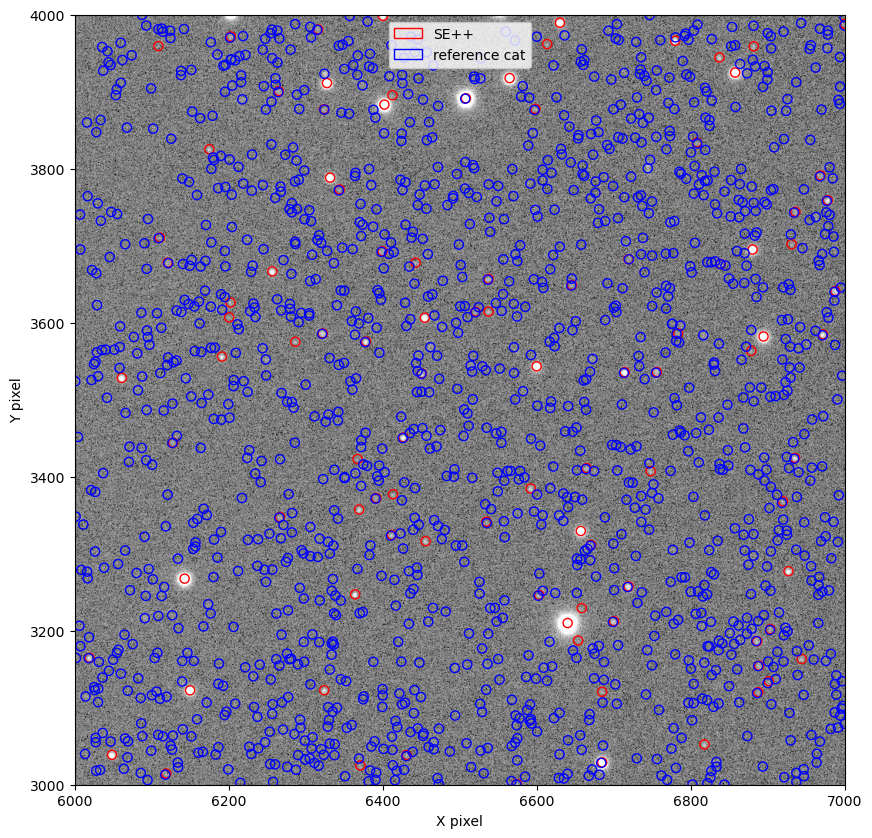

In [ ]:
from astropy.table import Table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from matplotlib.patches import Circle
from astropy.visualization import (
    ImageNormalize,
    ZScaleInterval,
    PercentileInterval,
    AsinhStretch,
    LogStretch,
    SqrtStretch
)


def plot_ImageAndDetectedSources(image, header, cat, cosmos_finalcat, pixel_range=None):
    # pixel_range = ( (xmin, xmax), (ymin, ymax) )

    wcs = WCS(header)
    cosmos_final_x, cosmos_final_y = wcs.world_to_pixel_values(cosmos_finalcat['RA'], cosmos_finalcat['DEC'])
    
    cosmos_finalcat['pixel_centroid_x'] = cosmos_final_x
    cosmos_finalcat['pixel_centroid_y'] = cosmos_final_y
    
    if pixel_range is not None:
        xmin = pixel_range[0][0]
        xmax = pixel_range[0][1]
        ymin = pixel_range[1][0]
        ymax = pixel_range[1][1]

        cat_plot = cat[
            (xmin <= cat['pixel_centroid_x'])
            & (cat['pixel_centroid_x'] < xmax)
            & (ymin <= cat['pixel_centroid_y'])
            & (cat['pixel_centroid_y'] < ymax)
        ]
        
        cosmos_finalcat_plot = cosmos_finalcat[
            (xmin <= cosmos_finalcat['pixel_centroid_x'])
            & (cosmos_finalcat['pixel_centroid_x'] < xmax)
            & (ymin <= cosmos_finalcat['pixel_centroid_y'])
            & (cosmos_finalcat['pixel_centroid_y'] < ymax)
        ]

        image_plot = image[ymin:ymax, xmin:xmax]

    else:
        ymin, xmin = 0, 0
        ymax, xmax = image.shape

        cat_plot = cat
        cosmos_finalcat_plot = cosmos_finalcat
        image_plot = image

    norm = ImageNormalize(
        image_plot,
        interval=PercentileInterval(99.5),
        stretch=AsinhStretch()
    )

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.imshow(
        image_plot,
        cmap='gray',
        norm=norm,
        origin='lower',
        extent=[xmin, xmax, ymin, ymax]
    )

    radius_pix = 5.94

    for i, (x, y) in enumerate(zip(
    cat_plot['pixel_centroid_x'],
    cat_plot['pixel_centroid_y']
    )):
        ax.add_patch(
            Circle(
                (x, y),
                radius=radius_pix,
                fill=False,
                edgecolor='red',
                linewidth=1, 
                label='SE++' if i == 0 else None
            )
        )
    
    for i, (x, y) in enumerate(zip(
            cosmos_finalcat_plot['pixel_centroid_x'],
            cosmos_finalcat_plot['pixel_centroid_y']
        )):
            ax.add_patch(
                Circle(
                    (x, y),
                    radius=radius_pix,
                    fill=False,
                    edgecolor='blue',
                    linewidth=1, 
                    label='reference cat' if i == 0 else None
                )
            )

    ax.set_xlabel('X pixel')
    ax.set_ylabel('Y pixel')
    ax.legend()

    plt.show()


# --------------- main -----------------


COSMOS = 1
band = 'm600'
data_range = ( (6000, 7000), (3000, 4000) )

data_path = get_image_path(COSMOS, band)
catalog_path = get_catalog_path(COSMOS, band)

with fits.open(data_path) as hdul:
        data = hdul[0].data

cat = Table.read(catalog_path)

# Catalog sources cut by valid mask
x = np.rint(cat["pixel_centroid_x"]).astype(int)
y = np.rint(cat["pixel_centroid_y"]).astype(int)
inside = (
    (x >= 0) & (x < valid_mask.shape[1]) &
    (y >= 0) & (y < valid_mask.shape[0])
)

cat = cat[inside]
x = x[inside]
y = y[inside]

cat["mask"] = valid_mask[y, x]
cat = cat[cat["mask"] == True]

# S/N calculation and cuts
cat["SNR"] = cat["aperture_flux"] / cat["aperture_flux_err"]

cat_snrcut = cat[
    (cat["SNR"] > 5)
    & (cat["aperture_flags"] == 0)
]
cat_flagcut = cat[
    cat["aperture_flags"] == 0
]

print(f"\n\n**{band}**")
print(f"Original data : {len(cat)}")
print(f"After flag cut : {len(cat_flagcut)}")
print(f"After SNR cut : {len(cat_snrcut)}")

plot_ImageAndDetectedSources(
    data,
    header,
    cat_flagcut,
    COSMOS_FINALCAT, 
    data_range
)


## Check sky background in every band
The statistics below use only pixels with positive weight. A robust sigma-clipped median is a useful first check: values close to zero suggest that the images are sky-subtracted, while a persistent non-zero median suggests a residual sky level.

band            N       median         mean          std          p01          p99
------------------------------------------------------------------------------
m400      613,067        1.196       1.2182       2.0381      -3.5709       6.6252
m425      615,938       1.1003       1.1117       1.6985      -2.9709       6.1631
m450      630,463       1.4886       1.5152       3.8524      -10.955       14.126
m475      626,854       1.0783       1.0972       1.9984      -3.7686       9.2402
m500      601,717       1.4366       1.4819       3.7186      -7.1839       12.392
m525      606,495       1.1589       1.1827       2.1602      -3.9761       9.7022
m550      614,786       1.5057       1.5822       5.6895      -16.312       23.909
m575      612,828       1.1407       1.1597       2.3199      -4.9384       14.358
m600      625,300       1.3457       1.3657       6.2669      -14.182       19.163
m625      621,874       1.3365       1.3802         2.74      -5.0823        11.13
m650    

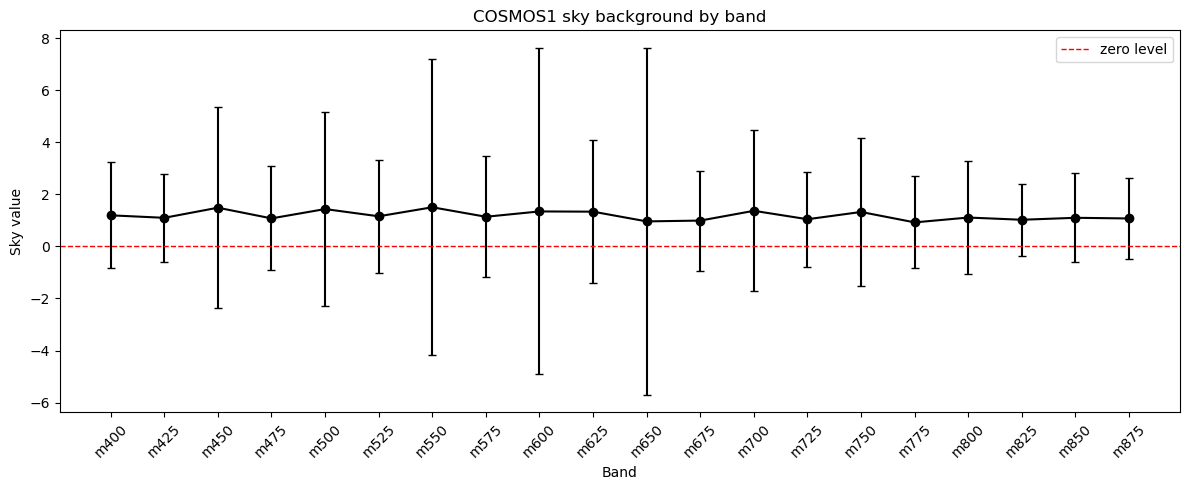

In [3]:
sky_results = []

# Sampling every 10th pixel keeps this diagnostic lightweight while
# retaining enough pixels to estimate the large-scale sky level.
for band in bands_7DT:
    image_path = get_image_path(COSMOS, band)
    weight_path = get_image_path(COSMOS, band, weight=True)
    if image_path is None or weight_path is None:
        continue

    with fits.open(image_path, memmap=True) as image_hdul, fits.open(weight_path, memmap=True) as weight_hdul:
        image = image_hdul[0].data
        weight = weight_hdul[0].data

        image_sample = np.asarray(image[::10, ::10], dtype=float)
        weight_sample = np.asarray(weight[::10, ::10], dtype=float)

    valid = (
        np.isfinite(image_sample)
        & np.isfinite(weight_sample)
        & (weight_sample > 0)
    )
    sky_pixels = image_sample[valid]

    sky_mean, sky_median, sky_std = sigma_clipped_stats(
        sky_pixels, sigma=3.0, maxiters=5
    )
    p01, p99 = np.percentile(sky_pixels, [1, 99])

    sky_results.append({
        'band': band,
        'n_valid': sky_pixels.size,
        'median': float(sky_median),
        'mean': float(sky_mean),
        'std': float(sky_std),
        'p01': float(p01),
        'p99': float(p99),
    })

print(f"{'band':<6} {'N':>10} {'median':>12} {'mean':>12} {'std':>12} {'p01':>12} {'p99':>12}")
print('-' * 78)
for result in sky_results:
    print(
        f"{result['band']:<6} {result['n_valid']:>10,d} "
        f"{result['median']:>12.5g} {result['mean']:>12.5g} "
        f"{result['std']:>12.5g} {result['p01']:>12.5g} {result['p99']:>12.5g}"
    )

bands_with_sky = [result['band'] for result in sky_results]
sky_medians = np.array([result['median'] for result in sky_results])
sky_stds = np.array([result['std'] for result in sky_results])

fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(
    bands_with_sky,
    sky_medians,
    yerr=sky_stds,
    fmt='o-',
    capsize=3,
    color='black',
)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='zero level')
ax.set_xlabel('Band')
ax.set_ylabel('Sky value')
ax.set_title(f'COSMOS{COSMOS} sky background by band')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
